In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm


In [2]:
# Load raw datasets
data_dir = "raw-f1-datasets/"

results = pd.read_csv(f"{data_dir}results.csv", na_values=r'\N')
races = pd.read_csv(f"{data_dir}races.csv", na_values=r'\N')
circuits = pd.read_csv(f"{data_dir}circuits.csv", na_values=r'\N')
pit_stops = pd.read_csv(f"{data_dir}pit_stops.csv", na_values=r'\N')

# Clean and aggregate Pit Stop Data
# Milliseconds column is most reliable metric for total pit lane time.
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

# Aggregate to find total pit stop time and total number of stops per driver per race
pit_stops_agg = pit_stops.groupby(['raceId', 'driverId']).agg(
    total_pit_time_ms=('milliseconds', 'sum'),
    num_pit_stops=('stop', 'max') # The highest stop number equals the total count
).reset_index()

# Convert milliseconds to seconds for interpretable regression coefficient later
pit_stops_agg['total_pit_time_sec'] = pit_stops_agg['total_pit_time_ms'] / 1000
pit_stops_agg.drop(columns=['total_pit_time_ms'], inplace=True)

# Clean Race Results
# positionOrder is superior to position for modeling because it provides a 
# strictly numeric final classification even for drivers who retired.
results_subset = results[['raceId', 'driverId', 'constructorId', 'grid', 
                          'positionOrder', 'points', 'statusId', 'laps']].copy()

# Clean Races & Circuits
races_subset = races[['raceId', 'year', 'round', 'circuitId', 'name']].rename(
    columns={'name': 'race_name'}
)
circuits_subset = circuits[['circuitId', 'circuitRef', 'name', 'location', 
                            'country', 'lat', 'lng']].rename(columns={'name': 'circuit_name'})

# Merge Pipeline
# Link circuit data to race events
races_circuits = pd.merge(races_subset, circuits_subset, on='circuitId', how='left')

# Attach race/circuit context to individual driver results
df_base = pd.merge(results_subset, races_circuits, on='raceId', how='left')

# Merge in aggregated pit stop performance
final_df = pd.merge(df_base, pit_stops_agg, on=['raceId', 'driverId'], how='left')

# Drivers who didn't pit will have NaN values, fill them with 0.
final_df['num_pit_stops'] = final_df['num_pit_stops'].fillna(0)
final_df['total_pit_time_sec'] = final_df['total_pit_time_sec'].fillna(0)

print(final_df.info())

# Save dataset to the repository
# final_df.to_csv("processed_f1_dataset.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   raceId              26759 non-null  int64  
 1   driverId            26759 non-null  int64  
 2   constructorId       26759 non-null  int64  
 3   grid                26759 non-null  int64  
 4   positionOrder       26759 non-null  int64  
 5   points              26759 non-null  float64
 6   statusId            26759 non-null  int64  
 7   laps                26759 non-null  int64  
 8   year                26759 non-null  int64  
 9   round               26759 non-null  int64  
 10  circuitId           26759 non-null  int64  
 11  race_name           26759 non-null  object 
 12  circuitRef          26759 non-null  object 
 13  circuit_name        26759 non-null  object 
 14  location            26759 non-null  object 
 15  country             26759 non-null  object 
 16  lat 

## NOTE: Pitstops only start getting recorded at 2011

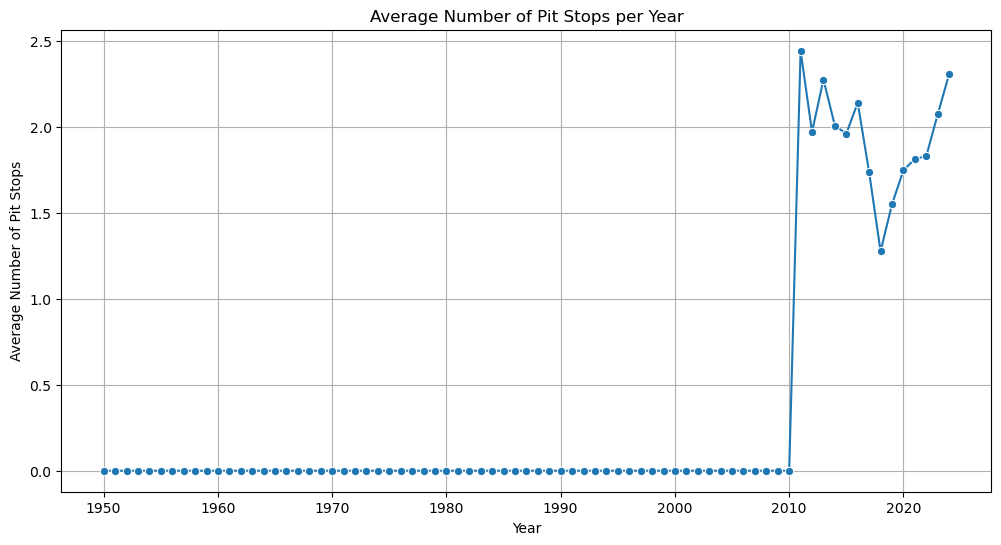

In [3]:
# graph showing average pit stops per year
avg_pit_stops_per_year = final_df.groupby('year')['num_pit_stops'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_pit_stops_per_year, x='year', y='num_pit_stops', marker='o')
plt.title('Average Number of Pit Stops per Year')
plt.xlabel('Year')
plt.ylabel('Average Number of Pit Stops')
plt.grid()
plt.show()

## ALSO: Drivers who ended up not finishing the race (DNF) may have 0 pit stops and 0 pit stop time, we should probably remove that from any analyses. We can use the StatusID column to filter out DNFs (any StatusID that =! 1) or include laps completed as a control var

In [4]:
# make a df with no dnfs in statusid and with data from 2011 onwards
no_dnf_df = final_df[(final_df['statusId'] == 1) & (final_df['year'] >= 2011)]
no_dnf_df.head()

,raceId,driverId,constructorId,grid,positionOrder,points,statusId,laps,year,round,circuitId,race_name,circuitRef,circuit_name,location,country,lat,lng,num_pit_stops,total_pit_time_sec
20776,841,20,9,1,1,25.0,1,58,2011,1,1,Australian Grand Prix,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,2.0,46.639
20777,841,1,1,2,2,18.0,1,58,2011,1,1,Australian Grand Prix,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,2.0,46.426
20778,841,808,4,6,3,15.0,1,58,2011,1,1,Australian Grand Prix,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,2.0,50.218
20779,841,4,6,5,4,12.0,1,58,2011,1,1,Australian Grand Prix,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,3.0,72.165
20780,841,17,9,3,5,10.0,1,58,2011,1,1,Australian Grand Prix,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,3.0,72.176


## Single LinReg

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     74.60
Date:                Fri, 29 May 2026   Prob (F-statistic):           7.57e-18
Time:                        04:34:19   Log-Likelihood:                -16422.
No. Observations:                5165   AIC:                         3.285e+04
Df Residuals:                    5163   BIC:                         3.286e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.0422      0

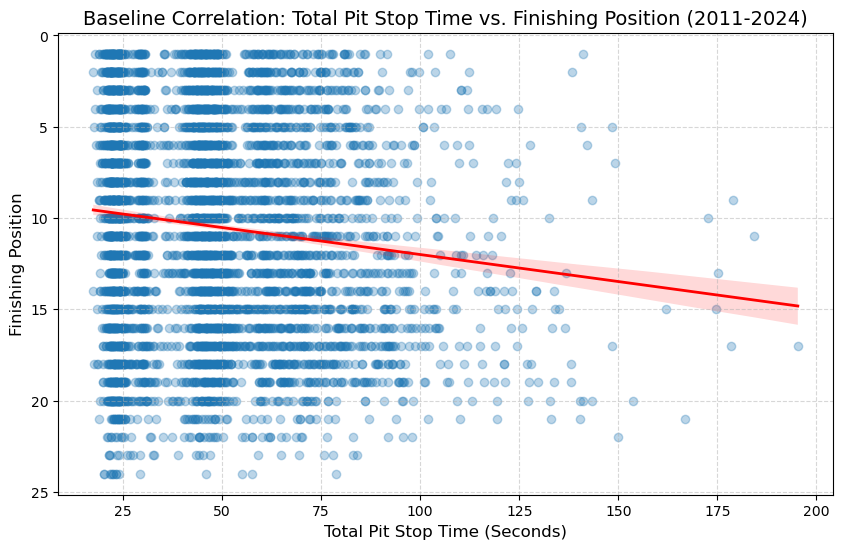

In [5]:
df = pd.read_csv("processed_f1_dataset.csv")

# Filter for the modern pit stop era and handle real-world outliers
# We exclude pre-2011 data (where pit times are 0) and filter out extreme outliers 
# (e.g., total pit times over 200 seconds, which usually indicate crash repairs or red flags).
model_df = df[(df['year'] >= 2011) & 
              (df['total_pit_time_sec'] > 0) & 
              (df['total_pit_time_sec'] < 200)].copy()

# Define variables
X = model_df['total_pit_time_sec']
y = model_df['positionOrder']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit and print the OLS model
model = sm.OLS(y, X).fit()
print(model.summary())

# Visualize the correlation
plt.figure(figsize=(10, 6))

# Use an alpha to handle overplotting, makes dense clusters of data easier to see
sns.regplot(x='total_pit_time_sec', y='positionOrder', data=model_df, 
            scatter_kws={'alpha': 0.3, 'color': '#1f77b4'}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Baseline Correlation: Total Pit Stop Time vs. Finishing Position (2011-2024)', fontsize=14)
plt.xlabel('Total Pit Stop Time (Seconds)', fontsize=12)
plt.ylabel('Finishing Position', fontsize=12)

# Invert the y-axis so 1st place is at the top of the chart
plt.gca().invert_yaxis() 
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

With the simple linear model, there is a signficant but very weak relationship between pitstop times and finishing position. However this one didn't take into account starting position, how pit stop times vary by track, or time per pit stop.

                            OLS Regression Results                            
Dep. Variable:          places_gained   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     53.65
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.77e-13
Time:                        04:34:19   Log-Likelihood:                -15348.
No. Observations:                5119   AIC:                         3.070e+04
Df Residuals:                    5117   BIC:                         3.071e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.0753      0.369  

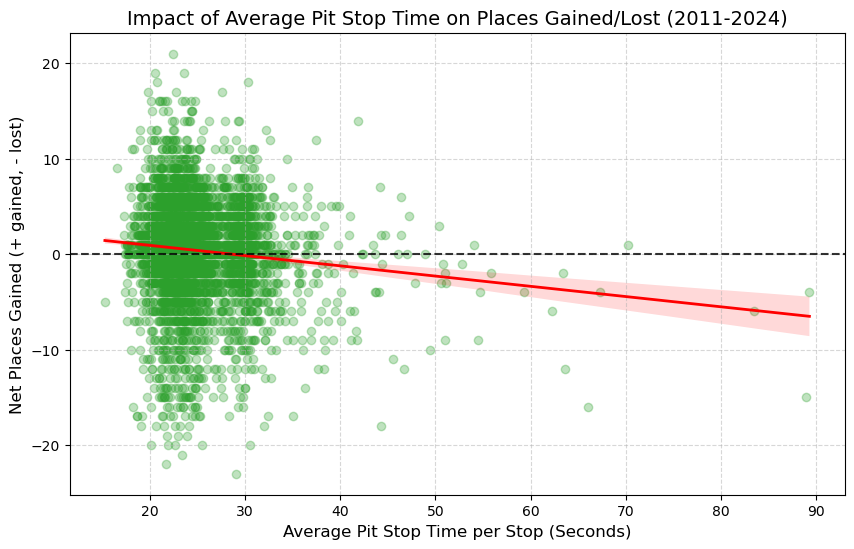

In [6]:
df = pd.read_csv("processed_f1_dataset.csv")

model_df = df[(df['year'] >= 2011) & 
              (df['grid'] > 0) & 
              (df['num_pit_stops'] > 0) & 
              (df['total_pit_time_sec'] > 0)].copy()

# Calculate dependent variable (Net Places Gained)
model_df['places_gained'] = model_df['grid'] - model_df['positionOrder']

# Calculate independent variable (Average Pit Stop Time)
model_df['avg_pit_time_sec'] = model_df['total_pit_time_sec'] / model_df['num_pit_stops']

# Filter out extreme average outliers (e.g., average time > 100 seconds due to heavy crash repairs)
model_df = model_df[model_df['avg_pit_time_sec'] < 100]

# Define variables for regression
X = model_df['avg_pit_time_sec']
y = model_df['places_gained']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit and print the OLS model
model = sm.OLS(y, X).fit()
print(model.summary())

# Visualize the correlation
plt.figure(figsize=(10, 6))

sns.regplot(x='avg_pit_time_sec', y='places_gained', data=model_df, 
            scatter_kws={'alpha': 0.3, 'color': '#2ca02c'}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Impact of Average Pit Stop Time on Places Gained/Lost (2011-2024)', fontsize=14)
plt.xlabel('Average Pit Stop Time per Stop (Seconds)', fontsize=12)
plt.ylabel('Net Places Gained (+ gained, - lost)', fontsize=12)

# Horizontal baseline at 0 (net neutral race)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Even after changing to avg pit stop time and changing to net places gained the R^2 remains super low (models explain no variance), indicating that pit stop time isn't a major determinant (other factors like driver skill, car performance, etc. matter more). The outliers are interesting however (super high avg pit stop time seems to be correlated with losing lots of places).